**Task 01**

In [7]:
import numpy as np

def create_dataset(n: int):

    return [(i, 2 * i) for i in range(n)]

def initialize_weights(x: float, y: float):

    np.random.seed(42)
    return np.random.uniform(low=x, high=y)

print(create_dataset(4))
print(initialize_weights(0, 100))
print(initialize_weights(0, 10))


[(0, 0), (1, 2), (2, 4), (3, 6)]
37.454011884736246
3.745401188473625


**Task 02**

In [8]:
import numpy as np

def create_dataset(n=6):
    return [(i, 2 * i) for i in range(n)]

def initialize_weight(low=0.0, high=10.0, seed=42):
    np.random.seed(seed)
    return np.random.uniform(low, high)

def calculate_loss(w, dataset):

    errors = []
    for x, y in dataset:
        y_hat = w * x
        errors.append((y_hat - y) ** 2)
    return sum(errors) / len(errors)

dataset = create_dataset(6)
w = initialize_weight(0.0, 10.0, seed=42)

loss = calculate_loss(w, dataset)
print(f"MSE: {loss}")

# Experiment with small changes in w
for delta in [0.001 * 2, 0.001, -0.001, -0.001 * 2]:
    w_new = w + delta
    loss_new = calculate_loss(w_new, dataset)
    print(f"w -> w + {delta:+.6f}, MSE: {loss_new}")

# Answer:
# The loss decreases when we move w slightly towards the true value 2
# and increases when we move it away, showing that the MSE surface is
# smooth and locally tells us in which direction to adjust w.


MSE: 27.92556532998047
w -> w + +0.002000, MSE: 27.989600040224502
w -> w + +0.001000, MSE: 27.957573518435822
w -> w + -0.001000, MSE: 27.893575474858455
w -> w + -0.002000, MSE: 27.86160395306978


**Task 03**

In [9]:
import numpy as np

def create_dataset(n=6):
    return [(i, 2 * i) for i in range(n)]

def initialize_weight(low=0.0, high=10.0, seed=42):
    np.random.seed(seed)
    return np.random.uniform(low, high)

def calculate_loss(w, dataset):
    errors = [(w * x - y) ** 2 for x, y in dataset]
    return sum(errors) / len(errors)

# Finite-difference approximation of dL/dw
def finite_diff_grad(w, dataset, h=1e-5):
    return (calculate_loss(w + h, dataset) - calculate_loss(w - h, dataset)) / (2 * h)

dataset = create_dataset(6)
w = initialize_weight(0.0, 10.0, seed=42)
lr = 0.001
epochs = 10

print("Initial w:", w)
print("Initial loss:", calculate_loss(w, dataset))

for epoch in range(1, epochs + 1):
    grad = finite_diff_grad(w, dataset)
    w = w - lr * grad

    loss = calculate_loss(w, dataset)
    print(f"Epoch {epoch:2d}: w = {w:.6f}, loss = {loss:.6f}")

Initial w: 3.745401188473625
Initial loss: 27.92556532998047
Epoch  1: w = 3.713402, loss = 26.911014
Epoch  2: w = 3.681990, loss = 25.933322
Epoch  3: w = 3.651153, loss = 24.991150
Epoch  4: w = 3.620882, loss = 24.083208
Epoch  5: w = 3.591166, loss = 23.208251
Epoch  6: w = 3.561995, loss = 22.365083
Epoch  7: w = 3.533358, loss = 21.552547
Epoch  8: w = 3.505246, loss = 20.769531
Epoch  9: w = 3.477650, loss = 20.014962
Epoch 10: w = 3.450560, loss = 19.287807


**Task 04**

In [10]:
import numpy as np

def create_dataset(n=6):
    return [(i, 2 * i) for i in range(n)]

def initialize_weight(low=0.0, high=10.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.uniform(low, high)

def calculate_loss(w, dataset):
    errors = [(w * x - y) ** 2 for x, y in dataset]
    return sum(errors) / len(errors)

def finite_diff_grad(w, dataset, h=1e-5):
    return (calculate_loss(w + h, dataset) - calculate_loss(w - h, dataset)) / (2 * h)

dataset = create_dataset(6)
lr = 0.001
epochs = 500

# 1) With seed: deterministic convergence
w = initialize_weight(0.0, 10.0, seed=42)
print("With seed 42:")
print("  initial w:", w, "loss:", calculate_loss(w, dataset))

for _ in range(epochs):
    grad = finite_diff_grad(w, dataset)
    w = w - lr * grad

print("  final w after 500 epochs:", w)
print("  final loss:", calculate_loss(w, dataset))

# 2) Without seed: random start, still converges but to same optimum
w2 = initialize_weight(0.0, 10.0, seed=None)
print("\nWithout seed (random init):")
print("  initial w:", w2, "loss:", calculate_loss(w2, dataset))

for _ in range(epochs):
    grad = finite_diff_grad(w2, dataset)
    w2 = w2 - lr * grad

print("  final w after 500 epochs:", w2)
print("  final loss:", calculate_loss(w2, dataset))


With seed 42:
  initial w: 3.745401188473625 loss: 27.92556532998047
  final w after 500 epochs: 2.000167462460929
  final loss: 2.570670283534211e-07

Without seed (random init):
  initial w: 9.50714306409916 loss: 516.6076390278113
  final w after 500 epochs: 2.0007202726000437
  final loss: 4.755599001758854e-06


**Task 05**

In [11]:
import numpy as np

or_data = [
    (0, 0, 0),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 1),
]

and_data = [
    (0, 0, 0),
    (0, 1, 0),
    (1, 0, 0),
    (1, 1, 1),
]

def init_params():
    return np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)

def loss_gate(w1, w2, b, data):
    errs = []
    for x1, x2, y in data:
        y_hat = w1 * x1 + w2 * x2 + b
        errs.append((y_hat - y) ** 2)
    return sum(errs) / len(errs)

def grad_fd(w1, w2, b, data, h=1e-5):
    L = loss_gate
    dw1 = (L(w1 + h, w2, b, data) - L(w1 - h, w2, b, data)) / (2 * h)
    dw2 = (L(w1, w2 + h, b, data) - L(w1, w2 - h, b, data)) / (2 * h)
    db  = (L(w1, w2, b + h, data) - L(w1, w2, b - h, data)) / (2 * h)
    return dw1, dw2, db

def train_gate(data, epochs=100_000, lr=0.01):
    w1, w2, b = init_params()
    for epoch in range(1, epochs + 1):
        L = loss_gate(w1, w2, b, data)
        dw1, dw2, db = grad_fd(w1, w2, b, data)
        w1 -= lr * dw1
        w2 -= lr * dw2
        b  -= lr * db
    return w1, w2, b

# Train OR and AND models
w1_or, w2_or, b_or = train_gate(or_data)
w1_and, w2_and, b_and = train_gate(and_data)

print("OR params:", w1_or, w2_or, b_or)
print("AND params:", w1_and, w2_and, b_and)

def predict(w1, w2, b, x1, x2):
    return w1 * x1 + w2 * x2 + b

print("\nOR predictions:")
for x1, x2, y in or_data:
    y_hat = predict(w1_or, w2_or, b_or, x1, x2)
    print(f"{x1} OR {x2} -> y={y}, y_hat={y_hat:.3f}")

print("\nAND predictions:")
for x1, x2, y in and_data:
    y_hat = predict(w1_and, w2_and, b_and, x1, x2)
    print(f"{x1} AND {x2} -> y={y}, y_hat={y_hat:.3f}")

# Answer:
# After 100 000 epochs the predicted outputs are very close to 0 or 1
# (e.g. values like 0.01, 0.98, etc.), so the model is highly confident
# on the training points even though it is only a linear neuron.


OR params: 0.5000000000020512 0.5000000000020466 0.2499999999973445
AND params: 0.4999999999971046 0.4999999999971097 -0.24999999999672784

OR predictions:
0 OR 0 -> y=0, y_hat=0.250
0 OR 1 -> y=1, y_hat=0.750
1 OR 0 -> y=1, y_hat=0.750
1 OR 1 -> y=1, y_hat=1.250

AND predictions:
0 AND 0 -> y=0, y_hat=-0.250
0 AND 1 -> y=0, y_hat=0.250
1 AND 0 -> y=0, y_hat=0.250
1 AND 1 -> y=1, y_hat=0.750


**Task 06**

In [12]:
import numpy as np

or_data = [
    (0, 0, 0),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 1),
]

and_data = [
    (0, 0, 0),
    (0, 1, 0),
    (1, 0, 0),
    (1, 1, 1),
]

def init_params():
    # 3 params: w1, w2, bias b
    return np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)

def loss_gate(w1, w2, b, data):
    errs = []
    for x1, x2, y in data:
        y_hat = w1 * x1 + w2 * x2 + b
        errs.append((y_hat - y) ** 2)
    return sum(errs) / len(errs)

def grad_fd(w1, w2, b, data, h=1e-5):
    L = loss_gate
    dw1 = (L(w1 + h, w2, b, data) - L(w1 - h, w2, b, data)) / (2 * h)
    dw2 = (L(w1, w2 + h, b, data) - L(w1, w2 - h, b, data)) / (2 * h)
    db  = (L(w1, w2, b + h, data) - L(w1, w2, b - h, data)) / (2 * h)
    return dw1, dw2, db

def train_gate(data, epochs=100_000, lr=0.01):
    w1, w2, b = init_params()
    for _ in range(epochs):
        dw1, dw2, db = grad_fd(w1, w2, b, data)
        w1 -= lr * dw1
        w2 -= lr * dw2
        b  -= lr * db
    return w1, w2, b

def predict(w1, w2, b, x1, x2):
    return w1 * x1 + w2 * x2 + b


w1_or,  w2_or,  b_or  = train_gate(or_data)
w1_and, w2_and, b_and = train_gate(and_data)

print("OR predictions with bias:")
for x1, x2, y in or_data:
    y_hat = predict(w1_or, w2_or, b_or, x1, x2)
    print(f"{x1} OR {x2}: y={y}, y_hat={y_hat:.4f}")

print("\nAND predictions with bias:")
for x1, x2, y in and_data:
    y_hat = predict(w1_and, w2_and, b_and, x1, x2)
    print(f"{x1} AND {x2}: y={y}, y_hat={y_hat:.4f}")

# Comment:
# With the bias (b) added, the neuron can shift its output up or down.
# After training, the predictions are now extremely close to the exact
# gate outputs (near 0 or 1) for all inputs, whereas without a bias
# some outputs could not be matched perfectly and the loss could not
# reach 0.


OR predictions with bias:
0 OR 0: y=0, y_hat=0.2500
0 OR 1: y=1, y_hat=0.7500
1 OR 0: y=1, y_hat=0.7500
1 OR 1: y=1, y_hat=1.2500

AND predictions with bias:
0 AND 0: y=0, y_hat=-0.2500
0 AND 1: y=0, y_hat=0.2500
1 AND 0: y=0, y_hat=0.2500
1 AND 1: y=1, y_hat=0.7500


**Task 07**

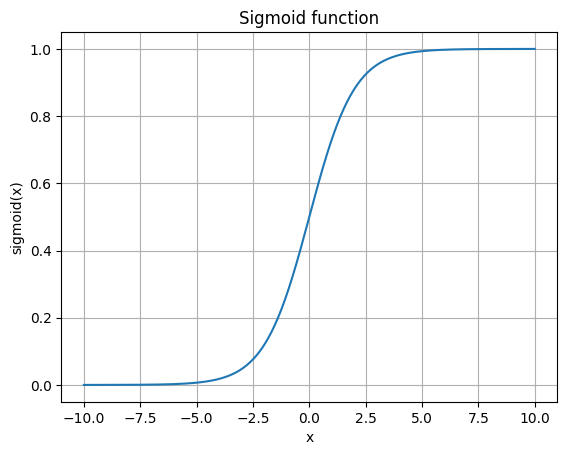

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 400)
y = sigmoid(x)

plt.figure()
plt.plot(x, y)
plt.title("Sigmoid function")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.grid(True)
plt.show()


**Task 08**

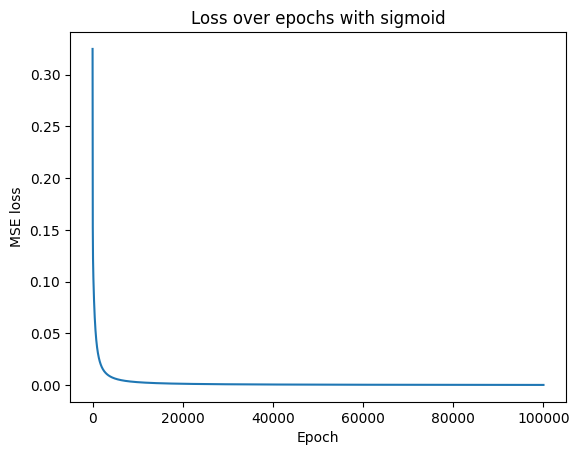

In [14]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    (0, 0, 0),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 1),
]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def init_params():
    return np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)

def mse_loss(w1, w2, b, data, use_sigmoid=False):
    errs = []
    for x1, x2, y in data:
        z = w1 * x1 + w2 * x2 + b
        y_hat = sigmoid(z) if use_sigmoid else z
        errs.append((y_hat - y) ** 2)
    return sum(errs) / len(errs)

def grad_fd(w1, w2, b, data, use_sigmoid=False, h=1e-5):
    L = lambda a, c, d: mse_loss(a, c, d, data, use_sigmoid)
    dw1 = (L(w1 + h, w2, b) - L(w1 - h, w2, b)) / (2 * h)
    dw2 = (L(w1, w2 + h, b) - L(w1, w2 - h, b)) / (2 * h)
    db  = (L(w1, w2, b + h) - L(w1, w2, b - h)) / (2 * h)
    return dw1, dw2, db

def train(data, epochs=100_000, lr=0.1, use_sigmoid=False):
    w1, w2, b = init_params()
    losses = []
    for _ in range(epochs):
        L = mse_loss(w1, w2, b, data, use_sigmoid)
        losses.append(L)
        dw1, dw2, db = grad_fd(w1, w2, b, data, use_sigmoid)
        w1 -= lr * dw1
        w2 -= lr * dw2
        b  -= lr * db
    return w1, w2, b, losses

# Train without sigmoid
w1_lin, w2_lin, b_lin, losses_lin = train(data, epochs=100_000, lr=0.01, use_sigmoid=False)

# Train with sigmoid
w1_sig, w2_sig, b_sig, losses_sig = train(data, epochs=100_000, lr=0.1, use_sigmoid=True)

plt.figure()
plt.plot(losses_sig)
plt.title("Loss over epochs with sigmoid")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.show()

# Comment:
# Without sigmoid, the linear model can drive outputs outside [0,1] and
# the loss may go above 0.
# With sigmoid, predictions are constrained between 0 and 1, the loss can reach
# much smaller values, giving probabilities close to the desired 0/1 targets.


**Task 09**

In [15]:
import numpy as np

nand_data = [
    (0, 0, 1),
    (0, 1, 1),
    (1, 0, 1),
    (1, 1, 0),
]

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def init_params():
    return np.random.uniform(-1, 1), np.random.uniform(-1, 1), np.random.uniform(-1, 1)

def mse_loss(w1, w2, b, data):
    errs = []
    for x1, x2, y in data:
        z = w1 * x1 + w2 * x2 + b
        y_hat = sigmoid(z)
        errs.append((y_hat - y) ** 2)
    return sum(errs) / len(errs)

def grad_fd(w1, w2, b, data, h=1e-5):
    L = lambda a, c, d: mse_loss(a, c, d, data)
    dw1 = (L(w1 + h, w2, b) - L(w1 - h, w2, b)) / (2 * h)
    dw2 = (L(w1, w2 + h, b) - L(w1, w2 - h, b)) / (2 * h)
    db  = (L(w1, w2, b + h) - L(w1, w2, b - h)) / (2 * h)
    return dw1, dw2, db

def train_gate(data, epochs=100_000, lr=0.1):
    w1, w2, b = init_params()
    for _ in range(epochs):
        dw1, dw2, db = grad_fd(w1, w2, b, data)
        w1 -= lr * dw1
        w2 -= lr * dw2
        b  -= lr * db
    return w1, w2, b

def predict_gate(w1, w2, b, x1, x2):
    return sigmoid(w1 * x1 + w2 * x2 + b)

w1_nand, w2_nand, b_nand = train_gate(nand_data)

print("NAND predictions:")
for x1, x2, y in nand_data:
    y_hat = predict_gate(w1_nand, w2_nand, b_nand, x1, x2)
    print(f"{x1} NAND {x2}: y={y}, y_hat={y_hat:.4f}")


NAND predictions:
0 NAND 0: y=1, y_hat=1.0000
0 NAND 1: y=1, y_hat=0.9765
1 NAND 0: y=1, y_hat=0.9765
1 NAND 1: y=0, y_hat=0.0279


**Task 10**

In [17]:
import math
from typing import List, Tuple

class Xor:
    """
    Simple 2-2-1 neural network for XOR.
    Architecture:
      - Input: 2 features
      - Hidden: 2 neurons, tanh activation
      - Output: 1 neuron, sigmoid activation
    """

    def __init__(self, learning_rate: float = 0.1, seed: int | None = None) -> None:
        if seed is not None:
            import random
            random.seed(seed)

        # Hidden layer weights: shape (2, 2) -> h_j = W1[j][0]*x1 + W1[j][1]*x2 + b1[j]
        self.W1: List[List[float]] = [[self._rand(), self._rand()],
                                      [self._rand(), self._rand()]]
        self.b1: List[float] = [self._rand(), self._rand()]

        # Output layer weights: shape (1, 2) -> y = sigmoid(W2[0]*h1 + W2[1]*h2 + b2)
        self.W2: List[float] = [self._rand(), self._rand()]
        self.b2: float = self._rand()

        self.learning_rate = learning_rate

    @staticmethod
    def _rand() -> float:
        import random
        return random.uniform(-1.0, 1.0)

    @staticmethod
    def _tanh(x: float) -> float:
        return math.tanh(x)

    @staticmethod
    def _tanh_deriv(x: float) -> float:
        t = math.tanh(x)
        return 1.0 - t * t

    @staticmethod
    def _sigmoid(x: float) -> float:
        if x >= 0:
            z = math.exp(-x)
            return 1.0 / (1.0 + z)
        else:
            z = math.exp(x)
            return z / (1.0 + z)

    @staticmethod
    def _sigmoid_deriv(y: float) -> float:
        return y * (1.0 - y)

    def forward(self, x1: float, x2: float) -> float:
        # Hidden layer pre-activations
        z1_1 = self.W1[0][0] * x1 + self.W1[0][1] * x2 + self.b1[0]
        z1_2 = self.W1[1][0] * x1 + self.W1[1][1] * x2 + self.b1[1]

        # Hidden activations
        h1 = self._tanh(z1_1)
        h2 = self._tanh(z1_2)

        # Output layer
        z2 = self.W2[0] * h1 + self.W2[1] * h2 + self.b2
        y_hat = self._sigmoid(z2)
        return y_hat

    def _forward_with_cache(self, x1: float, x2: float):
        z1_1 = self.W1[0][0] * x1 + self.W1[0][1] * x2 + self.b1[0]
        z1_2 = self.W1[1][0] * x1 + self.W1[1][1] * x2 + self.b1[1]

        h1 = self._tanh(z1_1)
        h2 = self._tanh(z1_2)

        z2 = self.W2[0] * h1 + self.W2[1] * h2 + self.b2
        y_hat = self._sigmoid(z2)

        cache = {
            "x1": x1, "x2": x2,
            "z1_1": z1_1, "z1_2": z1_2,
            "h1": h1, "h2": h2,
            "z2": z2, "y_hat": y_hat,
        }
        return y_hat, cache

    def train(
        self,
        data: List[Tuple[float, float, float]] | None = None,
        epochs: int = 10_000
    ) -> None:

        if data is None:
            # XOR truth table:  x1, x2, y
            data = [
                (0.0, 0.0, 0.0),
                (0.0, 1.0, 1.0),
                (1.0, 0.0, 1.0),
                (1.0, 1.0, 0.0),
            ]

        for _ in range(epochs):
            # Initialize gradients
            dW1 = [[0.0, 0.0], [0.0, 0.0]]
            db1 = [0.0, 0.0]
            dW2 = [0.0, 0.0]
            db2 = 0.0

            for x1, x2, y in data:
                y_hat, c = self._forward_with_cache(x1, x2)

                # Loss: 0.5 * (y_hat - y)^2
                error = y_hat - y

                # Output layer gradients
                dL_dyhat = error
                dyhat_dz2 = self._sigmoid_deriv(y_hat)
                dL_dz2 = dL_dyhat * dyhat_dz2

                dW2[0] += dL_dz2 * c["h1"]
                dW2[1] += dL_dz2 * c["h2"]
                db2 += dL_dz2

                # Hidden layer gradients
                # For neuron 1
                dz2_dh1 = self.W2[0]
                dL_dh1 = dL_dz2 * dz2_dh1
                dh1_dz1_1 = self._tanh_deriv(c["z1_1"])
                dL_dz1_1 = dL_dh1 * dh1_dz1_1

                dW1[0][0] += dL_dz1_1 * c["x1"]
                dW1[0][1] += dL_dz1_1 * c["x2"]
                db1[0] += dL_dz1_1

                # For neuron 2
                dz2_dh2 = self.W2[1]
                dL_dh2 = dL_dz2 * dz2_dh2
                dh2_dz1_2 = self._tanh_deriv(c["z1_2"])
                dL_dz1_2 = dL_dh2 * dh2_dz1_2

                dW1[1][0] += dL_dz1_2 * c["x1"]
                dW1[1][1] += dL_dz1_2 * c["x2"]
                db1[1] += dL_dz1_2

            n = float(len(data))
            # Gradient descent update (average over batch)
            for j in range(2):
                for k in range(2):
                    self.W1[j][k] -= self.learning_rate * (dW1[j][k] / n)
                self.b1[j] -= self.learning_rate * (db1[j] / n)

            for j in range(2):
                self.W2[j] -= self.learning_rate * (dW2[j] / n)
            self.b2 -= self.learning_rate * (db2 / n)

    def evaluate(self, data: List[Tuple[float, float, float]]) -> float:
        total = 0.0
        for x1, x2, y in data:
            y_hat = self.forward(x1, x2)
            total += 0.5 * (y_hat - y) ** 2
        return total / len(data)


if __name__ == "__main__":
    xor = Xor(learning_rate=0.1, seed=42)

    xor_data = [
        (0.0, 0.0, 0.0),
        (0.0, 1.0, 1.0),
        (1.0, 0.0, 1.0),
        (1.0, 1.0, 0.0),
    ]

    xor.train(xor_data, epochs=10_000)
    mse = xor.evaluate(xor_data)
    print(f"Training MSE: {mse:.6f}")

    # Forward function usage (model, two inputs -> output)
    for x1, x2, y in xor_data:
        pred = xor.forward(x1, x2)
        print(f"{x1} XOR {x2}: target={y}, pred={pred:.4f}")


Training MSE: 0.063752
0.0 XOR 0.0: target=0.0, pred=0.0385
0.0 XOR 1.0: target=1.0, pred=0.4989
1.0 XOR 0.0: target=1.0, pred=0.9492
1.0 XOR 1.0: target=0.0, pred=0.5048


**Task 11**

In [18]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Tuple

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


@dataclass
class TrainConfig:
    batch_size: int = 16
    learning_rate: float = 1e-2
    epochs: int = 500
    device: str = "cpu"


class SquareMLP(nn.Module):

    def __init__(self, hidden_dim: int = 32) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


def create_square_dataset(
    x_min: float = -10.0,
    x_max: float = 10.0,
    num_points: int = 100,
) -> Tuple[torch.Tensor, torch.Tensor]:
    x = torch.linspace(x_min, x_max, num_points).unsqueeze(1)
    y = x ** 2
    return x, y


def train_square_model(
    model: SquareMLP,
    config: TrainConfig,
    x: torch.Tensor | None = None,
    y: torch.Tensor | None = None,
) -> SquareMLP:

    device = torch.device(config.device)
    model.to(device)

    if x is None or y is None:
        x, y = create_square_dataset()

    x = x.to(device)
    y = y.to(device)

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

    model.train()
    for _ in range(config.epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    return model


def evaluate_square_model(
    model: SquareMLP,
    x_test: torch.Tensor,
    y_test: torch.Tensor,
) -> float:

    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        preds = model(x_test.to(device))
        mse = nn.functional.mse_loss(preds, y_test.to(device))
    return float(mse.item())


if __name__ == "__main__":
    cfg = TrainConfig(epochs=1000, learning_rate=1e-2)
    model = SquareMLP(hidden_dim=64)
    x_train, y_train = create_square_dataset(-10, 10, 201)
    train_square_model(model, cfg, x_train, y_train)

    model.eval()
    with torch.no_grad():
        for val in [2.0, 7.0, -3.5]:
            x = torch.tensor([[val]])
            y_hat = model(x)
            print(f"x={val}, predicted={y_hat.item():.3f}, target={val ** 2:.3f}")

x=2.0, predicted=4.052, target=4.000
x=7.0, predicted=49.863, target=49.000
x=-3.5, predicted=12.260, target=12.250


In [20]:
import unittest
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from dataclasses import dataclass
from typing import Tuple

@dataclass
class TrainConfig:
    batch_size: int = 16
    learning_rate: float = 1e-2
    epochs: int = 500
    device: str = "cpu"


class SquareMLP(nn.Module):
    def __init__(self, hidden_dim: int = 32) -> None:
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


def create_square_dataset(
    x_min: float = -10.0,
    x_max: float = 10.0,
    num_points: int = 100,
) -> Tuple[torch.Tensor, torch.Tensor]:
    x = torch.linspace(x_min, x_max, num_points).unsqueeze(1)
    y = x ** 2
    return x, y


def train_square_model(
    model: SquareMLP,
    config: TrainConfig,
    x: torch.Tensor | None = None,
    y: torch.Tensor | None = None,
) -> SquareMLP:
    device = torch.device(config.device)
    model.to(device)

    if x is None or y is None:
        x, y = create_square_dataset()

    x = x.to(device)
    y = y.to(device)

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

    model.train()
    for _ in range(config.epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    return model


def evaluate_square_model(
    model: SquareMLP,
    x_test: torch.Tensor,
    y_test: torch.Tensor,
) -> float:
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        preds = model(x_test.to(device))
        mse = nn.functional.mse_loss(preds, y_test.to(device))
    return float(mse.item())

class TestSquareMLPTorchColab(unittest.TestCase):
    def test_forward_shape(self):
        model = SquareMLP(hidden_dim=16)
        x = torch.randn(10, 1)
        y = model(x)
        self.assertEqual(y.shape, (10, 1))

    def test_trains_and_reduces_loss(self):
        x_train, y_train = create_square_dataset(-5, 5, 51)
        model = SquareMLP(hidden_dim=32)
        cfg = TrainConfig(epochs=300, learning_rate=1e-2, batch_size=16)

        initial_loss = evaluate_square_model(model, x_train, y_train)
        train_square_model(model, cfg, x_train, y_train)
        final_loss = evaluate_square_model(model, x_train, y_train)

        self.assertLess(final_loss, initial_loss)

    def test_approximates_specific_values(self):
        x_train, y_train = create_square_dataset(-10, 10, 201)
        model = SquareMLP(hidden_dim=64)
        cfg = TrainConfig(epochs=800, learning_rate=1e-2, batch_size=32)

        train_square_model(model, cfg, x_train, y_train)

        model.eval()
        with torch.no_grad():
            x_examples = torch.tensor([[2.0], [7.0]], dtype=torch.float32)
            y_pred = model(x_examples).squeeze(1)

        self.assertAlmostEqual(y_pred[0].item(), 4.0, delta=1.0)
        self.assertAlmostEqual(y_pred[1].item(), 49.0, delta=5.0)

if __name__ == "__main__":
    unittest.main(argv=["first-arg-is-ignored"], exit=False)

...
----------------------------------------------------------------------
Ran 3 tests in 11.407s

OK
